# Análisis estadístico del Estudio de Desempleo

- Autor: Juan Ernesto Díaz Noguez

## Resumen

Este reporte describe los resultados obtenidos del análisis estadístico del Estudio del desempleo, el cual forma parte del Reto. La muestra es de 50 personas desempleadas en la industria manufacturera a las cuales se recolectaron variables cuantitativas como: semanas de dempleo, edad, educación y años en el trabajo anterior. De igual manera se recolectaron variables cualitativas como estado civil (si la persona está soltera o casada), si es o no cabeza de familia, si contaba o no con un puesto de relacioando a la administración y si su ocupación es en ventas.

El analisis permitió identificar las principales características de los datos, su variabilidad, distribución y presencia de valores atípicos.

## Introducción

El objetivo del análisis es describir las características de la muestra de personas desempleadas mediante el uso de diferentes medidas estadísticas. Para ello, se analizaron las medidas de tendencia central, variabilidad y forma de las variables cuantitativas, tomando en consideración la normalidad y presencia de valores atípicos. Para las variables cualitativas se analizaron la moda y sus frecuencias.

# Importación de librerias y datos

In [ ]:
! pip install statsmodels

In [2]:
import pandas as pd
import numpy as np
from statsmodels.stats.diagnostic import normal_ad

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/juantacho/reto_estadistica/refs/heads/main/CasoDesempleoDatosOriginales.csv")
df

,Persona,Semanas,Edad,Educación,Casado,Cabeza Fam,Años Trab Ant,Administrador,Ventas
0,1,37,30,14,Casado,Cabeza familia,1,No Administrador,0
1,2,62,27,14,Casado,no cabeza familia,6,No Administrador,No Ventas
2,3,49,32,10,Soltero,Cabeza familia,11,No Administrador,No Ventas
3,4,73,44,11,Casado,no cabeza familia,2,No Administrador,No Ventas
4,5,8,21,14,Casado,Cabeza familia,2,No Administrador,No Ventas
5,6,15,26,13,Casado,no cabeza familia,7,Administrador,No Ventas
6,7,52,26,15,Casado,no cabeza familia,6,No Administrador,No Ventas
7,8,72,33,13,Soltero,Cabeza familia,6,No Administrador,No Ventas
8,9,11,27,12,Casado,Cabeza familia,8,No Administrador,No Ventas
9,10,13,33,12,Soltero,Cabeza familia,2,No Administrador,No Ventas


# Limpieza y estandarización de datos

In [13]:
display(df["Casado"].value_counts())

Casado
Casado     35
Soltero    15
Name: count, dtype: int64

In [14]:
df["Casado"] = df["Casado"].map({
    "Casado": True,
    "Soltero": False
})

In [15]:
display(df["Casado"].value_counts())

Casado
True     35
False    15
Name: count, dtype: int64

In [16]:
display(df["Cabeza Fam"].value_counts())

Cabeza Fam
Cabeza familia       34
no cabeza familia    16
Name: count, dtype: int64

In [17]:

df["Cabeza Fam"] = df["Cabeza Fam"].map({
    "Cabeza familia": True,
    "no cabeza familia": False
})

In [18]:
display(df["Cabeza Fam"].value_counts())

Cabeza Fam
True     34
False    16
Name: count, dtype: int64

In [19]:
display(df["Administrador"].value_counts())

Administrador
No Administrador    45
Administrador        5
Name: count, dtype: int64

In [20]:
df["Administrador"] = df["Administrador"].map({
    "Administrador": True,
    "No Administrador": False
})

In [21]:
display(df["Administrador"].value_counts())

Administrador
False    45
True      5
Name: count, dtype: int64

In [22]:
display(df["Ventas"].value_counts())

Ventas
No Ventas    40
Ventas        9
0             1
Name: count, dtype: int64

In [23]:
df["Ventas"] = df["Ventas"].map({
    "Ventas": True,
    "No Ventas": False,
    "1": True,
    "0": False
})

In [24]:
display(df["Ventas"].value_counts())

Ventas
False    41
True      9
Name: count, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Persona        50 non-null     int64
 1   Semanas        50 non-null     int64
 2   Edad           50 non-null     int64
 3   Educación      50 non-null     int64
 4   Casado         50 non-null     bool 
 5   Cabeza Fam     50 non-null     bool 
 6   Años Trab Ant  50 non-null     int64
 7   Administrador  50 non-null     bool 
 8   Ventas         50 non-null     bool 
dtypes: bool(4), int64(5)
memory usage: 2.3 KB


In [26]:
df.set_index("Persona", inplace=True)
print(df.columns.to_list())

['Semanas', 'Edad', 'Educación', 'Casado', 'Cabeza Fam', 'Años Trab Ant', 'Administrador', 'Ventas']


## Método

Se realizó un análisis estadístico descriptivo sobre una muestra de 50 observaciones. Para las variables cuantitativas se calcularon la media, mediana, moda, desviación estándar, rango intercuartílico y sesgo. También se utilizaron histogramas y diagramas de caja para observar la forma de las distribuciones y detectar valores atípicos. La normalidad fue evaluada mediante la prueba de Anderson-Darling, utilizando un nivel de significancia de α = 0.05. Para las variables consideradas normales en la práctica se utilizó la regla empírica, mientras que para aquellas que no presentaron una distribución normal se utilizó la desigualdad de Chebyshev. Para las variables cualitativas se calcularon la moda y las frecuencias absoluta, relativa y porcentual, además de representar su distribución mediante gráficas de barras.

# Selección de variables cuantitativas y cualitativas

## Variables involucradas

Las variables cuantitativas analizadas fueron semanas de desempleo, edad, educación y años de trabajo anterior. Las variables cualitativas fueron casado, cabeza de familia, administrador y ventas. La variable persona funciona únicamente como identificador de cada observación y no fue considerada como una característica para el análisis estadístico.

In [27]:
cuantitativas = [
    "Semanas",
    "Edad",
    "Educación",
    "Años Trab Ant"

]

cualitativas = [
    "Casado",
    "Cabeza Fam",
    "Administrador",
    "Ventas"
]

# Presentación de medidas resumen

In [28]:
display(df[cuantitativas].describe())

,Semanas,Edad,Educación,Años Trab Ant
count,50.000000,50.000000,50.000000,50.000000
mean,43.360000,34.600000,13.520000,8.360000
std,23.680492,9.059891,2.689663,5.844097
min,4.000000,20.000000,7.000000,1.000000
25%,23.500000,27.250000,12.000000,6.000000
50%,39.500000,33.000000,14.000000,8.000000
75%,61.250000,39.750000,15.000000,11.000000
max,98.000000,62.000000,19.000000,30.000000


## Cálculo de las demás medidas resumen y variables necesarias

In [29]:
resumen_cuantitativas = pd.DataFrame({
    "Media": df[cuantitativas].mean(),
    "Mediana": df[cuantitativas].median(),
    "Moda": df[cuantitativas].mode().iloc[0],
    "Desviación estándar": df[cuantitativas].std(),
    "Varianza": df[cuantitativas].var(),
    "Mínimo": df[cuantitativas].min(),
    "Q1": df[cuantitativas].quantile(0.25),
    "Q3": df[cuantitativas].quantile(0.75),
    "Máximo": df[cuantitativas].max(),
    "Sesgo": df[cuantitativas].skew()

})

resumen_cuantitativas

,Media,Mediana,Moda,Desviación estándar,Varianza,Mínimo,Q1,Q3,Máximo,Sesgo
Semanas,43.36,39.5,37.0,23.680492,560.765714,4,23.50,61.25,98,0.342321
Edad,34.60,33.0,33.0,9.059891,82.081633,20,27.25,39.75,62,1.031968
Educación,13.52,14.0,15.0,2.689663,7.234286,7,12.00,15.00,19,-0.360561
Años Trab Ant,8.36,8.0,6.0,5.844097,34.153469,1,6.00,11.00,30,1.473241


In [30]:
resumen_cuantitativas["Rango"] = (resumen_cuantitativas["Máximo"] - resumen_cuantitativas["Mínimo"])

resumen_cuantitativas["RIQ"] = (resumen_cuantitativas["Q3"] - resumen_cuantitativas["Q1"])

resumen_cuantitativas["Coeficiente de variación"] = (resumen_cuantitativas["Desviación estándar"] / resumen_cuantitativas["Media"] * 100)

In [31]:
resumen_cuantitativas["Límite inferior (2 Desviación estándar)"] = (resumen_cuantitativas["Media"] - 2 * resumen_cuantitativas["Desviación estándar"])
resumen_cuantitativas["Límite superior (2 Desviación estándar)"] = (resumen_cuantitativas["Media"] + 2 * resumen_cuantitativas["Desviación estándar"])

In [32]:
resumen_cuantitativas = resumen_cuantitativas.round(2)

In [33]:
resumen_cuantitativas

,Media,Mediana,Moda,Desviación estándar,Varianza,Mínimo,Q1,Q3,Máximo,Sesgo,Rango,RIQ,Coeficiente de variación,Límite inferior (2 Desviación estándar),Límite superior (2 Desviación estándar)
Semanas,43.36,39.5,37.0,23.68,560.77,4,23.50,61.25,98,0.34,94,37.75,54.61,-4.00,90.72
Edad,34.60,33.0,33.0,9.06,82.08,20,27.25,39.75,62,1.03,42,12.50,26.18,16.48,52.72
Educación,13.52,14.0,15.0,2.69,7.23,7,12.00,15.00,19,-0.36,12,3.00,19.89,8.14,18.90
Años Trab Ant,8.36,8.0,6.0,5.84,34.15,1,6.00,11.00,30,1.47,29,5.00,69.91,-3.33,20.05


## Selección de medidas de resumen

La elección de las medidas de resumen se realizó considerando la distribución y los valores atípicos de cada variable. Para semanas de desempleo se consideraron la media y desviación estándar, debido a que no presenta valores atípicos y su distribución es normal en la práctica. Para edad y años de trabajo anterior se consideraron la mediana y el rango intercuartílico debido a la presencia de valores atípicos y distribuciones no normales. En educación, aunque la distribución es normal en la práctica, la presencia de un valor atípico hace conveniente utilizar medidas resistentes a valores extremos.

## Presentación de medidas resumen para datos categoricos

In [34]:
for variable in cualitativas:

    print(f"\n{variable}")

    print(f"\nModa: {df[variable].mode()[0]}")

    print(f"\nFrecuencia absoluta: {df[variable].value_counts()}")

    print("\nFrecuencia relativa:")

    print(df[variable].value_counts(normalize=True))

    print("\nFrecuencia porcentual:")

    print(df[variable].value_counts(normalize=True) * 100)




Casado

Moda: True

Frecuencia absoluta: Casado
True     35
False    15
Name: count, dtype: int64

Frecuencia relativa:
Casado
True     0.7
False    0.3
Name: proportion, dtype: float64

Frecuencia porcentual:
Casado
True     70.0
False    30.0
Name: proportion, dtype: float64

Cabeza Fam

Moda: True

Frecuencia absoluta: Cabeza Fam
True     34
False    16
Name: count, dtype: int64

Frecuencia relativa:
Cabeza Fam
True     0.68
False    0.32
Name: proportion, dtype: float64

Frecuencia porcentual:
Cabeza Fam
True     68.0
False    32.0
Name: proportion, dtype: float64

Administrador

Moda: False

Frecuencia absoluta: Administrador
False    45
True      5
Name: count, dtype: int64

Frecuencia relativa:
Administrador
False    0.9
True     0.1
Name: proportion, dtype: float64

Frecuencia porcentual:
Administrador
False    90.0
True     10.0
Name: proportion, dtype: float64

Ventas

Moda: False

Frecuencia absoluta: Ventas
False    41
True      9
Name: count, dtype: int64

Frecuencia rela

Para las variables cualitativas se utilizaron la moda y las frecuencias absoluta, relativa y porcentual, debido a que permiten identificar tanto la categoría que se presenta con mayor frecuencia como la proporción que representa cada categoría dentro de la muestra.

# Presentación de Histogramas y Box Plots para datos cuantitativos

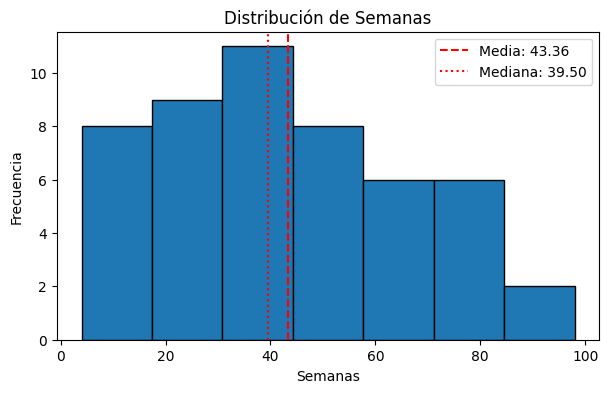

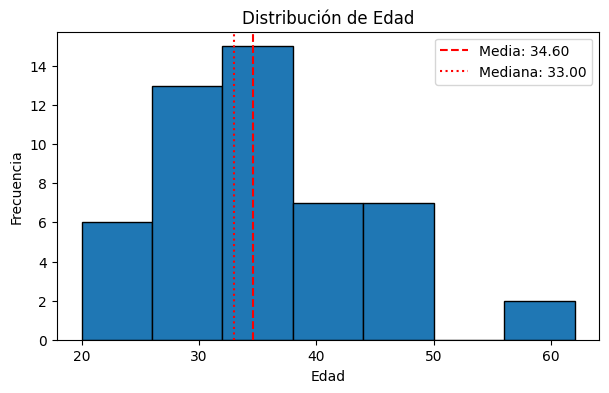

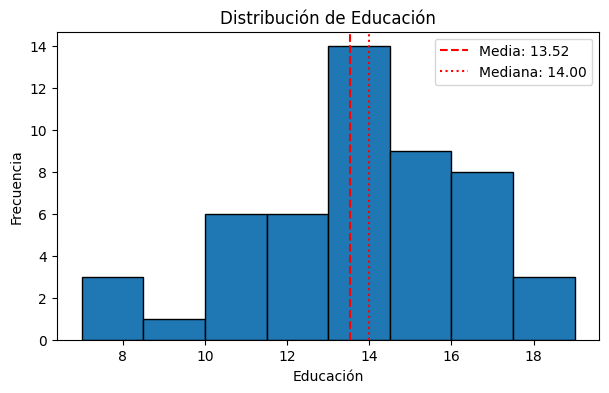

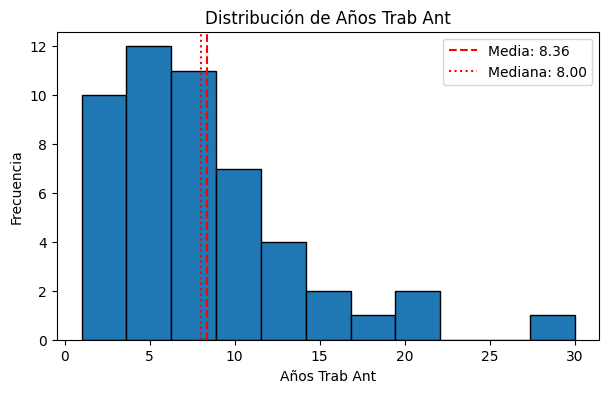

In [35]:
import matplotlib.pyplot as plt

for variable in cuantitativas:

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.hist(
        df[variable].dropna(),
        bins="auto",
        edgecolor="black"
    )

    ax.axvline(
        df[variable].mean(),
        linestyle="--",
        color="red",
        label=f"Media: {df[variable].mean():.2f}"
    )

    ax.axvline(
        df[variable].median(),
        linestyle=":",
        color="red",
        label=f"Mediana: {df[variable].median():.2f}"
    )

    ax.set_title(f"Distribución de {variable}")
    ax.set_xlabel(variable)
    ax.set_ylabel("Frecuencia")
    ax.legend()

    plt.show()

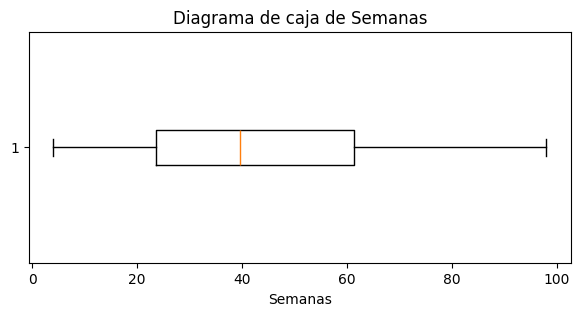

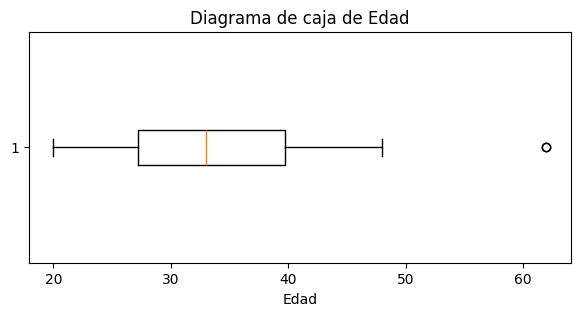

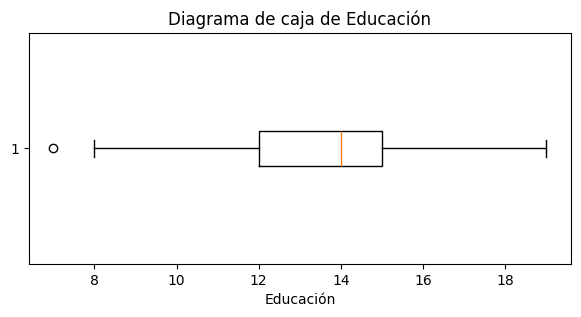

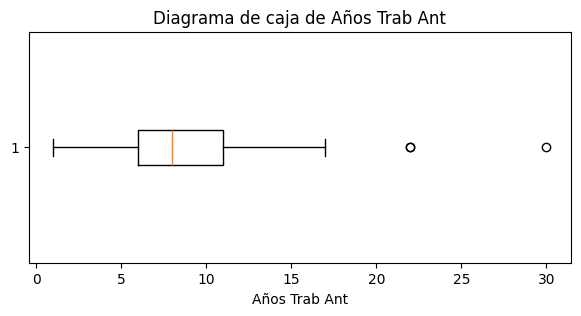

In [36]:
for variable in cuantitativas:

    fig, ax = plt.subplots(figsize=(7, 3))

    ax.boxplot(
        df[variable].dropna(),
        vert=False
    )

    ax.set_title(f"Diagrama de caja de {variable}")
    ax.set_xlabel(variable)

    plt.show()

In [37]:
alpha = 0.05
for variable in cuantitativas:

    a2, p_value = normal_ad(df[variable].dropna())

    if p_value > alpha:
        conclusion = "No se rechaza la normalidad"
    else:
        conclusion = "Se rechaza la normalidad"

    print(f"Variable: {variable}")
    print(f"A²: {a2:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Conclusión: {conclusion}")

Variable: Semanas
A²: 0.3146
p-value: 0.5335
Conclusión: No se rechaza la normalidad
Variable: Edad
A²: 0.7577
p-value: 0.0455
Conclusión: Se rechaza la normalidad
Variable: Educación
A²: 0.4732
p-value: 0.2327
Conclusión: No se rechaza la normalidad
Variable: Años Trab Ant
A²: 1.5820
p-value: 0.0004
Conclusión: Se rechaza la normalidad


# Análisis de resultados cuantitativos

## Semanas de desempleo

Las semanas de desempleo presentan una media de **43.36 semanas** y una desviación estándar de **23.68 semanas**. No se identificaron valores atípicos y la distribución puede considerarse normal en la práctica. Mediante la regla empírica se determinó que aproximadamente el 95% de los valores se encuentra a dos desviaciones estándar de la media, en un intervalo de **-4.00 a 90.72 semanas**. Aunque el límite inferior es negativo, este no posee una interpretación práctica, ya que el número de semanas de desempleo no puede ser menor que cero.

## Edad

La edad presenta una media de **34.60 años** y una mediana de **33 años**. Se identificaron valores atípicos superiores y la distribución no se considera normal. Por esta razón, la mediana y el rango intercuartílico permiten describirla sin verse tan afectados por los valores extremos. Mediante la desigualdad de Chebyshev se determinó que por lo menos el 75% de los valores se encuentra entre **16.48 y 52.72 años**.

## Educación

La educación presenta una media de **13.52 años** y una mediana de **14 años**. Su distribución puede considerarse normal en la práctica, aunque presenta un valor atípico inferior. Debido a la presencia de este valor se consideró el rango intercuartílico como medida de variabilidad. De acuerdo con la regla empírica, aproximadamente el 95% de los valores se encuentra entre **8.14 y 18.90 años de educación**.

## Años de trabajo anterior

Los años de trabajo anterior presentan una media de **8.36 años** y una mediana de **8 años**. La distribución presenta un sesgo hacia la derecha y varios valores atípicos superiores, por lo que no se considera normal. Mediante la desigualdad de Chebyshev se determinó que por lo menos el 75% de los valores se encuentra a dos desviaciones estándar de la media, entre **-3.33 y 20.05 años**. Aunque el límite inferior es negativo, este no posee una interpretación práctica, ya que el número de años de trabajo anterior no puede ser menor que cero.

# Presentación de gráficas de barras para datos cualitativos

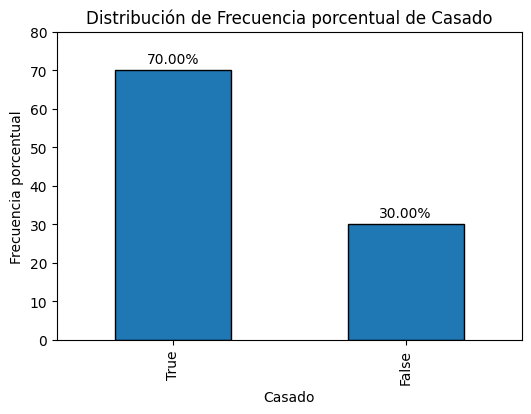

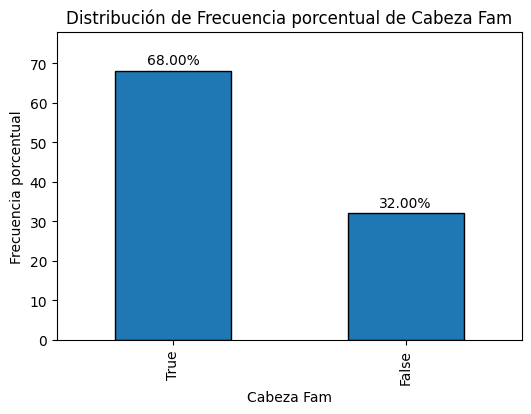

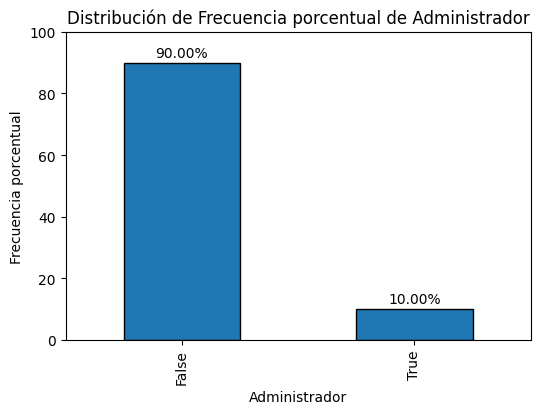

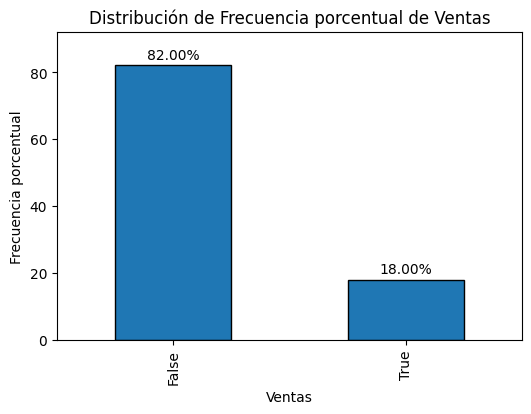

In [38]:
for variable in cualitativas:

    frecuencias = df[variable].value_counts(normalize=True) * 100

    fig, ax = plt.subplots(figsize=(6, 4))

    frecuencias.plot(
        kind="bar",
        edgecolor="black",
        ax=ax,
    )
    # add values on top of the bars
    for i, v in enumerate(frecuencias):
        ax.text(i, v + 1, f"{v:.2f}%", ha='center', va='bottom')
    ax.set_title(f"Distribución de Frecuencia porcentual de {variable}")
    ax.set_ylim(0, max(frecuencias) + 10)

    ax.set_xlabel(variable)

    ax.set_ylabel("Frecuencia porcentual")

    plt.show()

## Análisis de variables cualitativas

En cuanto a las variables cualitativas, **35 de las 50 personas se encuentran casadas, representando el 70% de la muestra**, mientras que el 30% son solteras. Asimismo, **34 personas (68%) son cabeza de familia**, siendo esta la categoría más frecuente.

Respecto a las características laborales, solamente **5 personas (10%) son administradores**, mientras que el 90% no lo son. Finalmente, **9 personas (18%) trabajan en ventas**, mientras que el 82% restante no pertenece a esta área.

# Conclusiones

El análisis permitió observar que las variables estudiadas presentan diferentes comportamientos, por lo que no es adecuado utilizar las mismas medidas estadísticas para todas ellas. Semanas de desempleo y educación presentan distribuciones normales en la práctica, mientras que edad y años de trabajo anterior presentan distribuciones no normales y valores atípicos. La presencia de estos valores hace importante considerar medidas resistentes, como la mediana y el rango intercuartílico, en lugar de depender únicamente de la media y la desviación estándar.

En las variables cualitativas se observa que la mayoría de las personas de la muestra están casadas y son cabeza de familia, mientras que una proporción considerablemente menor se desempeña como administrador o trabaja en ventas. En general, los resultados muestran la importancia de considerar tanto la distribución como los valores atípicos y el tipo de variable antes de seleccionar las medidas utilizadas para describir un conjunto de datos.